In [ ]:
# importando as bibliotecas.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
from scipy.fft import fft, fftshift, fftfreq

### Numpy em Opticas
---
### Exemplo 1
---
Vamos assumir que $x(t)$ seja um pulso exponencial e aplicaremos a Transformada de Fourier para visualizar o espectro do sinal. Podemos criar um código que simule o comportamento de um sinal $y(t)=x(t)cos(50t)$ e fazer a análise em frequência.

In [ ]:
# Declarando todas as funções para fazer os cálculos do sinal.
class FourierTransform:
  def __init__(self, w_0, t):
      self.w_0 = w_0
      self.t = t
      self.T = t[1] - t[0]
      self.freq = fftshift(fftfreq(len(t), self.T)) * 2 * np.pi

  def x_t(self):
      # Definindo o sinal x(t) - Pulso exponencial
      self.x_t = np.exp(-np.abs(self.t) * 2)

  def y_t(self):
      # Definindo o sinal y(t) = = x(t) * cos(50t)
      self.y_t = self.x_t * np.cos(self.w_0 * self.t)

  def scaling_factor(self):
      # Calculando o espectro inicial de x(t) para encontrar a constante de ajuste
      X_w_initial = fft(self.x_t)
      # Calculando um novo espectro movendo a frequencia zero para o centro.
      X_w_initial = fftshift(X_w_initial) / len(self.x_t)
      # Encontrando o scaling para melhor visualização.
      self.scaling_factor = 1 / np.max(np.abs(X_w_initial))

  def x_w(self):
      # Ajustando x(t) para que o espectro X(ω) tenha amplitude máxima de 1
      self.x_t_adjusted = self.scaling_factor * self.x_t
      X_w = fft(self.x_t_adjusted)
      self.X_w = fftshift(X_w) / len(self.x_t)

  def y_w(self):
      # Ajustando y(t) para que o espectro X(ω) tenha amplitude máxima de 1
      self.y_t_adjusted = self.scaling_factor * self.y_t
      Y_w = fft(self.y_t_adjusted)
      self.Y_w = fftshift(Y_w) / len(self.y_t)

  def get_results(self):
        # Retorna todos os dados necessários para plotar os gráficos fora da classe.
        return self.t, self.freq, self.x_t, self.y_t, np.abs(self.X_w), np.abs(self.Y_w)

In [ ]:
def plot(t, freq, x_t, y_t, X_w, Y_w):
    # Plotando os gráficos
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 4, figsize=(20, 3))
    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)

    # Sinal x(t) no domínio do tempo
    axes[0].plot(t, x_t, 'b')
    axes[0].set_xlabel('t (s)')
    axes[0].set_ylabel('$x(t)$ ajustado')
    axes[0].set_title('$x(t)$ ajustado no Domínio do Tempo')

    # Espectro X(ω) ajustado
    axes[1].plot(freq, np.abs(X_w), color = 'cyan')
    axes[1].axis([-100, 100, 0, 1.1])
    axes[1].set_xlabel('ω (rad/s)')
    axes[1].set_ylabel('$X(ω)$')
    axes[1].set_title('Espectro $X(ω)$ Ajustado')

    # Sinal y(t) no domínio do tempo
    axes[2].plot(t, y_t, 'r')
    axes[2].fill_between(t, y_t, color="red", alpha=0.3)  # Área preenchida para visualização
    axes[2].set_xlabel('t (s)')
    axes[2].set_ylabel('$y(t)$')
    axes[2].set_title('$y(t) = x(t) \cdot \cos(50t)$ no Domínio do Tempo')

    # Espectro Y(ω)
    axes[3].plot(freq, np.abs(Y_w), color = 'green')
    axes[3].axis([-100, 100, 0, 0.6])
    axes[3].set_xlabel('ω (rad/s)')
    axes[3].set_ylabel('$Y(ω)$')
    axes[3].set_title('Espectro $Y(ω)$')

    plt.show()

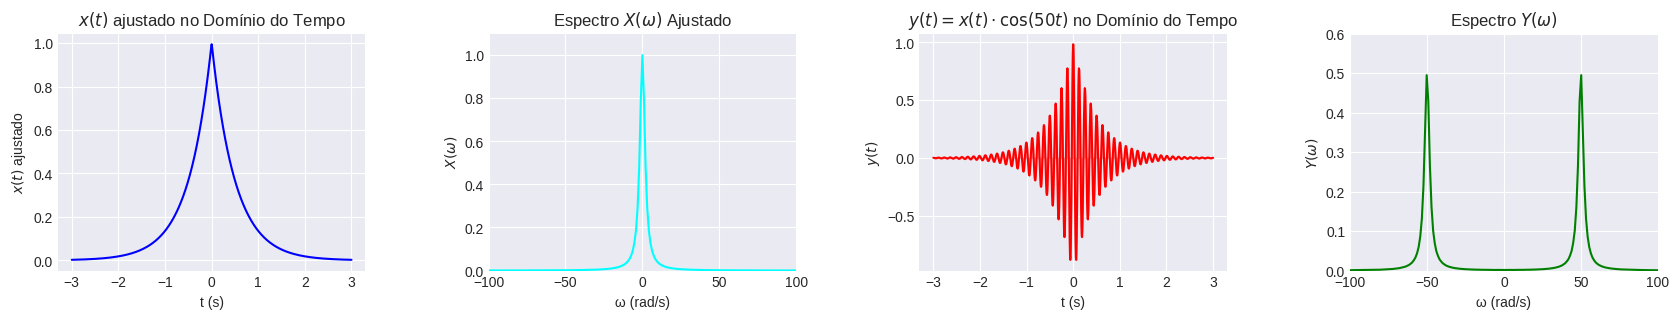

In [ ]:
# Parâmetros do sinal
t = np.linspace(-3, 3, 1000)
w_0 = 50

# Instanciando a classe da Transformda de Fourier
fourier_transform = FourierTransform(w_0, t)

# Geração e processamento do sinal
fourier_transform.x_t()
fourier_transform.y_t()
fourier_transform.scaling_factor()
fourier_transform.x_w()
fourier_transform.y_w()

# Obtém os resultados para plotagem
t, freq, x_t, y_t, X_w, Y_w = fourier_transform.get_results()

# Plota os sinais
plot(t, freq, x_t, y_t, X_w, Y_w)

### Conclusão:
Através desse código, foi possível visualizar e entender melhor a Transformada de Fourier aplicada a sinais contínuos, modelando a resposta em frequência de sinais temporais como o pulso exponencial e seu produto com um cosseno. Essa implementação facilitou a compreensão da relação entre o domínio do tempo e o domínio da frequência, especialmente ao observar como um sinal modulado em frequência, como $y(t) = x(t) * cos(w₀t)$, resulta em uma duplicação do espectro centrada nas frequências $±w₀$. Esse comportamento é uma característica fundamental da modulação em amplitude, que é uma base para sistemas de comunicação

### Exemplo 2:
---
Em __comunicações ópticas__, a dispersão cromática em uma fibra óptica faz com que diferentes comprimentos de onda (cores) de luz viajem a velocidades ligeiramente diferentes. Isso resulta em uma dispersão do pulso ao longo do tempo, à medida que o pulso percorre a fibra.

A __convolução__ pode ser usada para modelar esse fenômeno. O pulso transmitido pode ser convoluído com a resposta do sistema (fibra óptica com dispersão), resultando no pulso recebido que foi disperso.
> __Explicação Física:__
>+ $Pulso$ $Transmitido:$ O pulso de luz que é enviado pela fonte de luz (por exemplo, um laser) tem uma forma definida, modelada aqui como um pulso gaussiano.
>+ $Dispersão$ $Cromática$: Devido à dispersão cromática, diferentes comprimentos de onda da luz viajam a diferentes velocidades na fibra. Isso faz com que o pulso se espalhe no tempo à medida que percorre a fibra.
>+ $Pulso$ $Recebido$: O pulso recebido é mais largo e mais baixo em amplitude do que o pulso transmitido, devido à dispersão.
+ $Objetivo:$ Simular a propagação de um pulso de luz em uma fibra óptica e o efeito da dispersão cromática usando convolução com NumPy.

In [ ]:
# 1. Definir o pulso de luz transmitido (pulso gaussiano)
def pulso_gaussiano(t, amplitude, largura):
    return amplitude * np.exp(-t**2 / (2 * largura**2))

# 2. Definir a resposta impulsiva da fibra óptica (dispersão)
# A resposta é modelada como uma função gaussiana com uma largura maior (dispersão)
def resposta_dispersao(t, dispersao):
    return np.exp(-t**2 / (2 * dispersao**2))

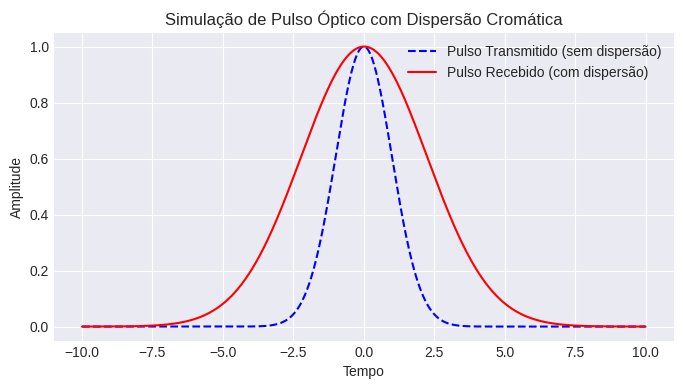

In [ ]:
# 3. Eixo temporal para a simulação.
# Tempo em unidades arbitrárias variando de -10 a 10.
t = np.linspace(-10, 10, 1000)

# 4. Gerar o pulso transmitido
amplitude = 1.0
# Largura do pulso original (antes da dispersão)
largura_pulso = 1.0
pulso_tx = pulso_gaussiano(t, amplitude, largura_pulso)

# 5. Definir a resposta do sistema (dispersão da fibra óptica)
# A dispersão vai "alargar" o pulso ao longo da fibra
largura_dispersao = 2.0
resposta_fibra = resposta_dispersao(t, largura_dispersao)

# 6. Realizar a convolução entre o pulso transmitido e a resposta da fibra (dispersão)
# Pulso recebido após a dispersão
pulso_rx = convolve(pulso_tx, resposta_fibra, mode='same')

# 7. Normalizar o pulso recebido
pulso_rx = pulso_rx / np.max(pulso_rx)

# 8. Visualizar os pulsos transmitido e recebido
plt.figure(figsize=(8, 4))
plt.plot(t, pulso_tx, label='Pulso Transmitido (sem dispersão)', color='blue', linestyle='--')
plt.plot(t, pulso_rx, label='Pulso Recebido (com dispersão)', color='red')
plt.title('Simulação de Pulso Óptico com Dispersão Cromática')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

>Neste exemplo, usamos a convolução para simular como um pulso óptico sofre dispersão cromática ao passar por uma fibra óptica. A convolução nos permite calcular a forma final do pulso recebido, considerando os efeitos de dispersão da fibra.
Esse tipo de análise é muito importante em comunicações ópticas, pois a dispersão cromática pode limitar a taxa de transmissão de dados e a distância máxima de transmissão sem regeneração do sinal.

Escolher as bibliotecas NumPy, SciPy e Matplotlib para esse tipo de simulação tem várias vantagens, especialmente para quem precisa de uma solução rápida, precisa e bem documentada para problemas de análise e visualização de dados científicos:
+ NumPy é projetada para manipulação e processamento rápido de arrays, sendo muito mais eficiente do que listas tradicionais do Python. Ela permite operações vetorizadas, o que significa que pode realizar cálculos em grandes conjuntos de dados em uma única operação, economizando tempo e processamento.
+ SciPy expande o que NumPy oferece, com funções matemáticas e científicas especializadas como a convolução, que seria difícil de implementar de forma precisa e rápida sem a ajuda de uma biblioteca. Isso torna SciPy ideal para cálculos complexos, como os necessários para simular fenômenos físicos (no caso, a dispersão do pulso).
+ Ambas as bibliotecas, NumPy e SciPy, são reconhecidas pela precisão matemática, sendo amplamente testadas e utilizadas em indústrias e laboratórios acadêmicos. Elas fornecem uma base confiável para simulações científicas e cálculos estatísticos, permitindo que os resultados obtidos sejam confiáveis e baseados em cálculos matemáticos robustos.
+ Matplotlib permite uma visualização detalhada e personalizável dos dados, essencial para interpretar o comportamento de simulações como a dispersão do pulso óptico. Além de gerar gráficos com boa aparência, Matplotlib é flexível e permite adicionar rótulos, títulos e legendas, melhorando a comunicação visual dos resultados.
  
### Conclusão:
O código cumpre bem o objetivo de simular a dispersão de um pulso óptico em uma fibra, utilizando convolução para calcular a influência da resposta impulsiva da fibra (dispersão) sobre o pulso inicial. Visualizar essa dispersão fornece uma compreensão clara de como o alargamento afeta o sinal, reforçando a importância de considerar a dispersão cromática em projetos de sistemas de comunicação óptica.

### Referências:
---
1. **OPPENHEIM, A. V.; WILLSKY, A. S.** *Signals and Systems*. 2ª ed. New Jersey: Prentice Hall, 1997.
